In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librairies chargées.")

Librairies chargées.


In [3]:
DATA_PATH = "online_shoppers_intention.csv"

if not os.path.exists(DATA_PATH):
    print("Upload ton fichier online_shoppers_intention.csv")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

df = pd.read_csv(DATA_PATH)

print(f"Dimensions initiales : {df.shape}")

n_duplicates = df.duplicated().sum()
if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"{n_duplicates} doublons supprimés.")

print(f"Dimensions finales : {df.shape}")
display(df.head())

Dimensions initiales : (12330, 18)
125 doublons supprimés.
Dimensions finales : (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
TARGET = "Revenue"

CAT_FEATURES = ["Month", "VisitorType", "Weekend"]

NUM_FEATURES = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

LOG_FEATURES = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "ProductRelated",
    "PageValues"
]

NORMAL_NUM_FEATURES = [col for col in NUM_FEATURES if col not in LOG_FEATURES]

df[TARGET] = df[TARGET].astype(int)

print("Colonnes catégorielles :", CAT_FEATURES)
print("Colonnes numériques normales :", NORMAL_NUM_FEATURES)
print("Colonnes avec log1p :", LOG_FEATURES)

In [5]:
# ============================================================
# Cellule 5 — Définition de la target et des features
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Target
TARGET = "Revenue"

# Vérification
if TARGET not in df.columns:
    raise ValueError(f"La colonne cible '{TARGET}' n'existe pas dans df. Colonnes disponibles : {df.columns.tolist()}")

# Conversion de Revenue en 0/1 si nécessaire
if df[TARGET].dtype == bool:
    df[TARGET] = df[TARGET].astype(int)
elif df[TARGET].dtype == object:
    df[TARGET] = df[TARGET].map({True: 1, False: 0, "TRUE": 1, "FALSE": 0, "True": 1, "False": 0}).astype(int)
else:
    df[TARGET] = df[TARGET].astype(int)

# Colonnes catégorielles
CAT_FEATURES = [
    "Month",
    "VisitorType",
    "Weekend"
]

# Colonnes numériques
NUM_FEATURES = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

# Colonnes sur lesquelles on applique log1p
LOG_FEATURES = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "ProductRelated",
    "PageValues"
]

# Colonnes numériques normales
NORMAL_NUM_FEATURES = [col for col in NUM_FEATURES if col not in LOG_FEATURES]

# Vérification des colonnes
required_cols = CAT_FEATURES + NUM_FEATURES + [TARGET]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes dans le dataset : {missing_cols}")

print("Target :", TARGET)
print("Colonnes catégorielles :", CAT_FEATURES)
print("Colonnes numériques normales :", NORMAL_NUM_FEATURES)
print("Colonnes transformées avec log1p :", LOG_FEATURES)
print("Shape du dataset :", df.shape)

Target : Revenue
Colonnes catégorielles : ['Month', 'VisitorType', 'Weekend']
Colonnes numériques normales : ['Administrative', 'Informational', 'BounceRates', 'ExitRates', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Colonnes transformées avec log1p : ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'ProductRelated', 'PageValues']
Shape du dataset : (12205, 18)


In [6]:
# ============================================================
# Cellule 6 — Split anti-leakage
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET]

# 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# DataFrame train pour EDA uniquement
train_df = X_train.copy()
train_df[TARGET] = y_train

print("Splits créés sans leakage :")
print(f"Train      : {X_train.shape} | Revenue=1 : {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Validation : {X_val.shape} | Revenue=1 : {y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"Test       : {X_test.shape} | Revenue=1 : {y_test.sum()} ({y_test.mean()*100:.2f}%)")

print("\nImportant : le preprocessing sera fitté uniquement sur X_train.")

Splits créés sans leakage :
Train      : (7323, 17) | Revenue=1 : 1145 (15.64%)
Validation : (2441, 17) | Revenue=1 : 381 (15.61%)
Test       : (2441, 17) | Revenue=1 : 382 (15.65%)

Important : le preprocessing sera fitté uniquement sur X_train.


In [7]:
# ============================================================
# Cellule 7 — EDA uniquement sur le train set
# ============================================================

print("Aperçu du train set")
display(train_df.head())

print("\nStatistiques descriptives du train set")
display(train_df.describe())

print("\nValeurs manquantes dans le train set")
missing = train_df.isnull().sum()
display(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante")

print("\nDistribution de Revenue dans le train set")
display(train_df[TARGET].value_counts().to_frame("count"))

print(f"\nTaux de Revenue=True dans le train : {train_df[TARGET].mean()*100:.2f}%")

Aperçu du train set


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
6829,3,251.814286,2,101.80,37,1722.814286,0.001026,0.007998,4.683076,0.0,Oct,1,1,1,2,Returning_Visitor,True,0
11021,5,39.500000,3,62.25,339,16138.290800,0.004779,0.020194,0.000000,0.0,Nov,2,2,3,2,Returning_Visitor,False,0
10496,0,0.000000,0,0.00,3,144.500000,0.000000,0.100000,0.000000,0.0,Nov,3,2,2,2,New_Visitor,False,0
406,3,66.333333,0,0.00,15,424.833333,0.000000,0.012500,0.000000,0.0,Mar,2,2,6,6,Returning_Visitor,False,0
2957,0,0.000000,0,0.00,6,129.000000,0.000000,0.050000,0.000000,0.0,May,2,2,4,4,Returning_Visitor,False,0



Statistiques descriptives du train set


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue
count,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000,7323.000000
mean,2.346716,82.983176,0.522190,36.041762,32.288816,1211.614734,0.020147,0.041192,6.016854,0.062270,2.142428,2.384542,3.132596,4.083572,0.156357
std,3.361468,181.535249,1.288019,147.095819,43.900147,1917.423427,0.045076,0.045997,18.914982,0.199455,0.925853,1.755669,2.400556,4.058148,0.363218
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,195.291667,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,619.520833,0.002857,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000
75%,4.000000,95.800000,0.000000,0.000000,39.000000,1504.328788,0.016327,0.048148,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000
max,27.000000,3398.750000,16.000000,2549.375000,584.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000



Valeurs manquantes dans le train set


'Aucune valeur manquante'


Distribution de Revenue dans le train set


,count
Revenue,
0,6178
1,1145



Taux de Revenue=True dans le train : 15.64%


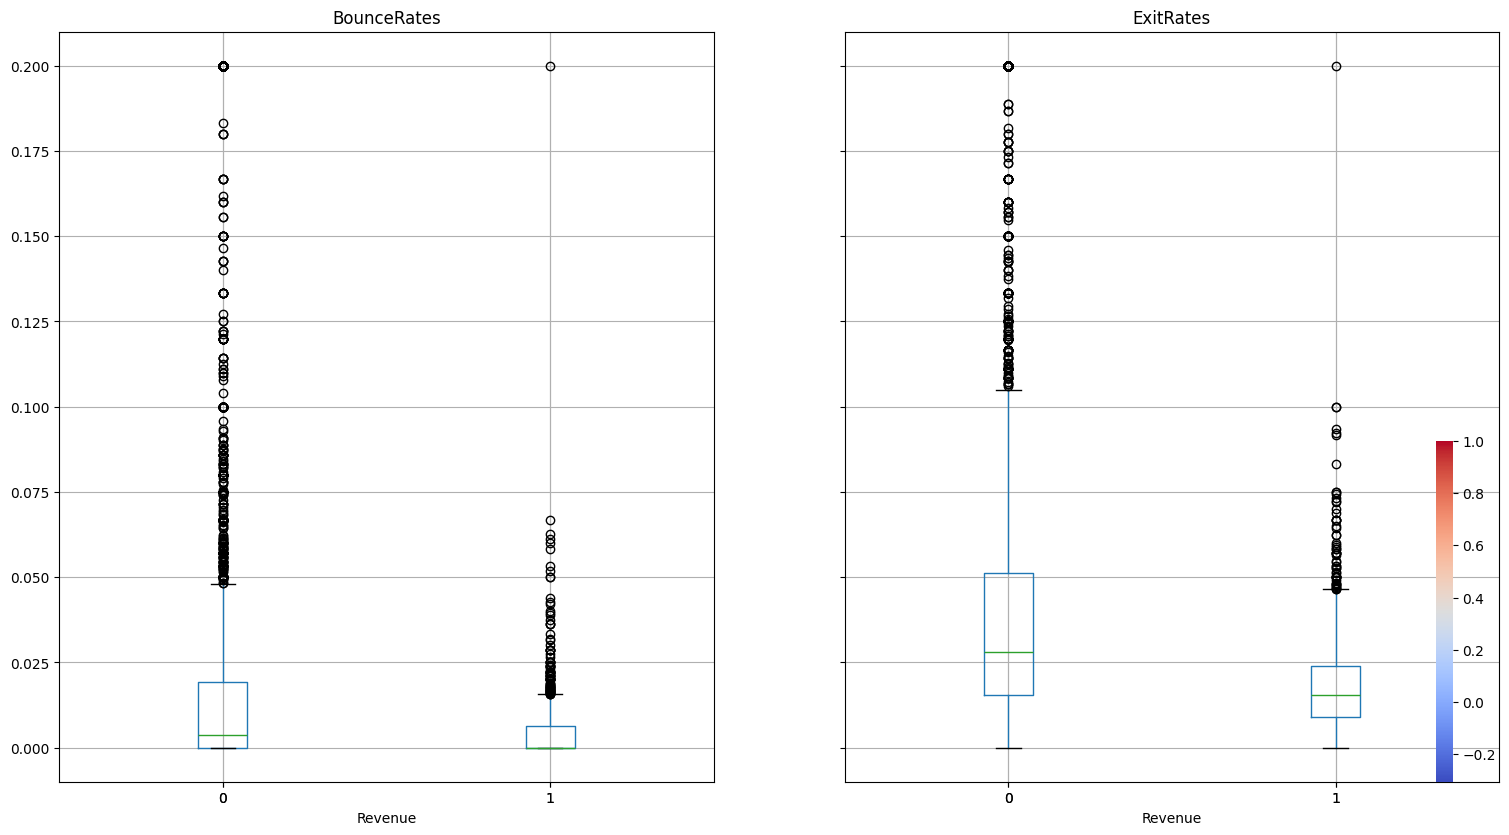

In [8]:
# ============================================================
# Cellule 8 — Visualisations EDA sur train uniquement
# ============================================================

MONTH_ORDER = ["Feb", "Mar", "Apr", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
months_ok = [m for m in MONTH_ORDER if m in train_df["Month"].unique()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA sur le train set uniquement", fontsize=14, fontweight="bold")

# 1. Distribution target
ax = axes[0, 0]
train_df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Distribution de Revenue")
ax.set_xticklabels(["Non-achat", "Achat"], rotation=0)
ax.set_ylabel("Nombre de sessions")

# 2. Taux d'achat par mois
ax = axes[0, 1]
month_rate = train_df.groupby("Month")[TARGET].mean()

if len(months_ok) > 0:
    month_rate = month_rate.reindex(months_ok)

(month_rate * 100).plot(kind="bar", ax=ax, edgecolor="black")
ax.axhline(train_df[TARGET].mean() * 100, linestyle="--", label="Moyenne train")
ax.set_title("Taux d'achat par mois")
ax.set_ylabel("Taux d'achat (%)")
ax.legend()

# 3. Taux d'achat par type de visiteur
ax = axes[0, 2]
visitor_rate = train_df.groupby("VisitorType")[TARGET].mean().sort_values(ascending=False) * 100
visitor_rate.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Taux d'achat par type de visiteur")
ax.set_ylabel("Taux d'achat (%)")

# 4. PageValues par classe
ax = axes[1, 0]
train_df.loc[train_df[TARGET] == 0, "PageValues"].clip(upper=100).hist(
    ax=ax,
    bins=40,
    alpha=0.6,
    density=True,
    label="Revenue=False"
)
train_df.loc[train_df[TARGET] == 1, "PageValues"].clip(upper=100).hist(
    ax=ax,
    bins=40,
    alpha=0.6,
    density=True,
    label="Revenue=True"
)
ax.set_title("Distribution de PageValues par classe")
ax.set_xlabel("PageValues")
ax.legend()

# 5. BounceRates / ExitRates
ax = axes[1, 1]
train_df.boxplot(
    column=["BounceRates", "ExitRates"],
    by=TARGET,
    ax=ax
)
ax.set_title("BounceRates / ExitRates par Revenue")
ax.set_xlabel("Revenue")
plt.suptitle("")

# 6. Corrélation numérique
ax = axes[1, 2]
corr_cols = NUM_FEATURES + [TARGET]
sns.heatmap(
    train_df[corr_cols].corr(),
    ax=ax,
    cmap="coolwarm",
    annot=False
)
ax.set_title("Corrélations numériques")

plt.tight_layout()
plt.show()

Skewness avant log1p, calculée sur le train uniquement :

Administrative_Duration             | avant :    5.656 | après log1p :    0.242
Informational_Duration              | avant :    7.406 | après log1p :    1.898
ProductRelated_Duration             | avant :    8.159 | après log1p :   -1.432
ProductRelated                      | avant :    3.918 | après log1p :   -0.050
PageValues                          | avant :    6.325 | après log1p :    1.788


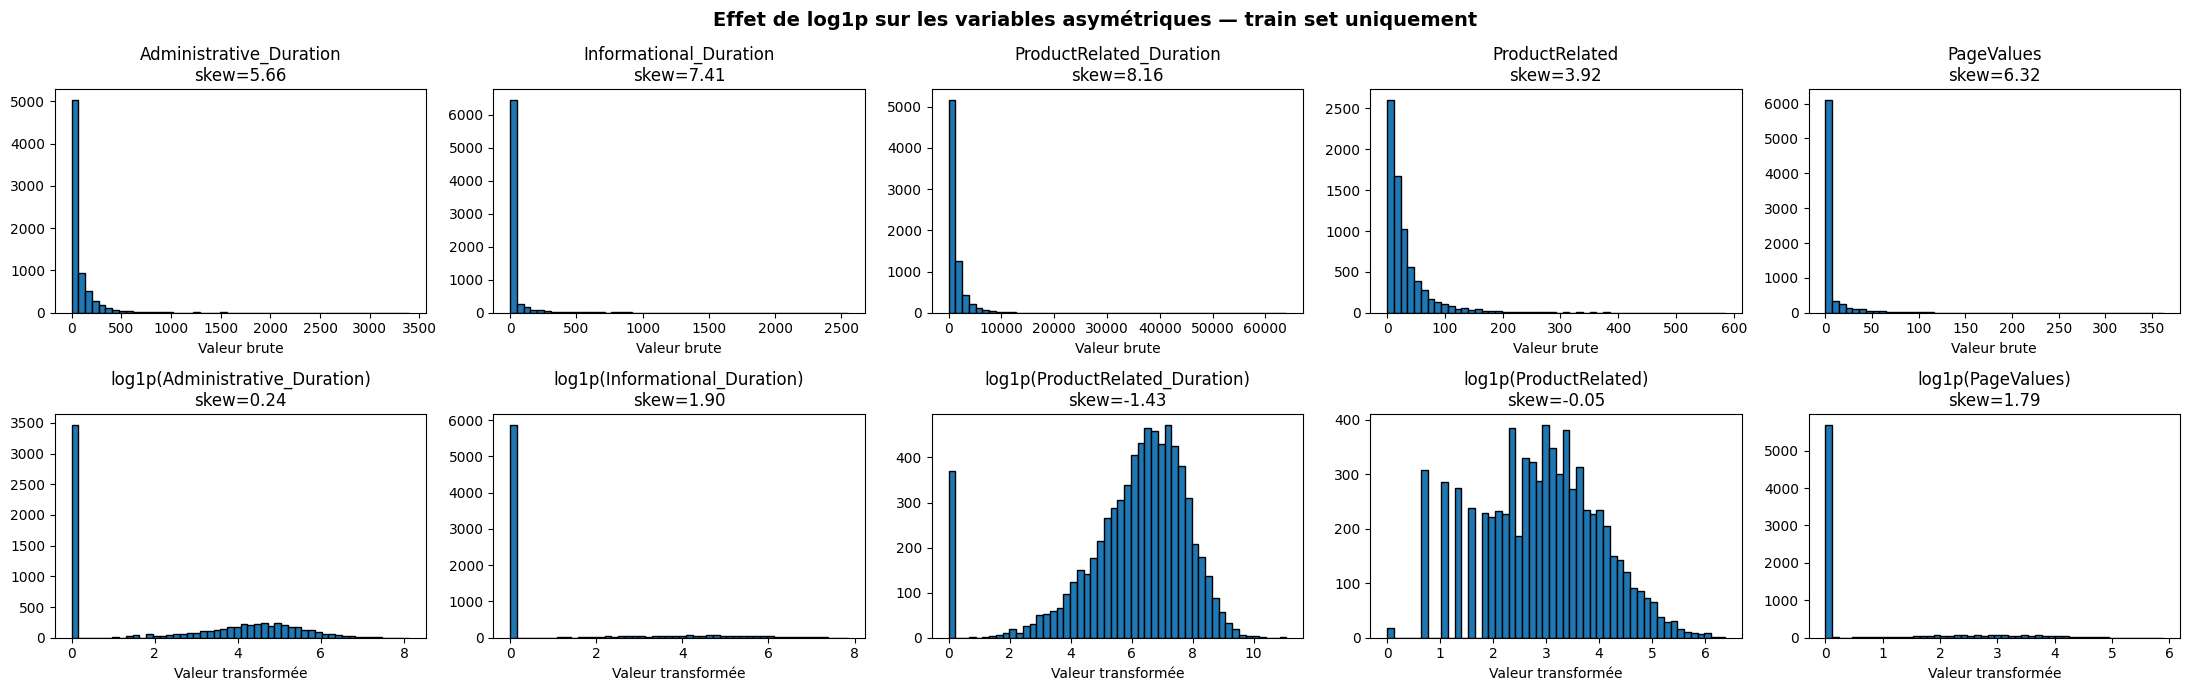

In [9]:
# ============================================================
# Cellule 9 — Analyse skewness avant / après log1p
# ============================================================

print("Skewness avant log1p, calculée sur le train uniquement :\n")

for col in LOG_FEATURES:
    before = train_df[col].skew()
    after = np.log1p(train_df[col]).skew()
    print(f"{col:35s} | avant : {before:8.3f} | après log1p : {after:8.3f}")

fig, axes = plt.subplots(2, len(LOG_FEATURES), figsize=(22, 7))
fig.suptitle("Effet de log1p sur les variables asymétriques — train set uniquement", fontsize=14, fontweight="bold")

for i, col in enumerate(LOG_FEATURES):
    axes[0, i].hist(train_df[col], bins=50, edgecolor="black")
    axes[0, i].set_title(f"{col}\nskew={train_df[col].skew():.2f}")
    axes[0, i].set_xlabel("Valeur brute")

    log_values = np.log1p(train_df[col])
    axes[1, i].hist(log_values, bins=50, edgecolor="black")
    axes[1, i].set_title(f"log1p({col})\nskew={log_values.skew():.2f}")
    axes[1, i].set_xlabel("Valeur transformée")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Cellule 10 — Preprocessing fitté uniquement sur X_train
# ============================================================

# Compatibilité entre versions sklearn
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

log_pipeline = Pipeline(steps=[
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_pipeline, LOG_FEATURES),
        ("num", num_pipeline, NORMAL_NUM_FEATURES),
        ("cat", encoder, CAT_FEATURES)
    ],
    remainder="drop"
)

# Fit uniquement sur le train
preprocessor.fit(X_train)

# Transform train / validation / test avec le même preprocessor
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Preprocessing terminé sans leakage.")
print("X_train_proc :", X_train_proc.shape)
print("X_val_proc   :", X_val_proc.shape)
print("X_test_proc  :", X_test_proc.shape)

Preprocessing terminé sans leakage.
X_train_proc : (7323, 29)
X_val_proc   : (2441, 29)
X_test_proc  : (2441, 29)


In [11]:
# ============================================================
# Cellule 11 — Fonction d'évaluation
# ============================================================

def evaluate_binary_model(model, X_eval, y_eval, threshold=0.5):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision_true": precision_score(y_eval, y_pred, zero_division=0),
        "Recall_true": recall_score(y_eval, y_pred, zero_division=0),
        "F1_true": f1_score(y_eval, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, y_prob),
        "PR_AUC": average_precision_score(y_eval, y_prob),
    }

    return metrics, y_pred, y_prob

print("Fonction d'évaluation prête.")

Fonction d'évaluation prête.


In [12]:
# ============================================================
# Cellule 12 — Section 3.3 : Controlled Degradation Experiment
# ============================================================

DEGRADATION_RATIOS = [1.00, 0.75, 0.50, 0.25, 0.10]

ADABOOST_N_ESTIMATORS = 100
ADABOOST_LEARNING_RATE = 1.0
TREE_MAX_DEPTH = 1
DECISION_THRESHOLD = 0.5

pos_idx = X_train.index[y_train == 1].to_numpy()
neg_idx = X_train.index[y_train == 0].to_numpy()

n_pos_total = len(pos_idx)
n_neg_total = len(neg_idx)

rng = np.random.default_rng(RANDOM_STATE)
pos_permutation = rng.permutation(pos_idx)

print("Composition du training set original :")
print(f"Revenue=True  : {n_pos_total} ({n_pos_total / len(y_train) * 100:.2f}%)")
print(f"Revenue=False : {n_neg_total} ({n_neg_total / len(y_train) * 100:.2f}%)")

print("\nValidation set fixe :")
print(f"X_val : {X_val.shape} | Revenue=True : {y_val.sum()} ({y_val.mean()*100:.2f}%)")

print("\nTest set non utilisé dans cette expérience.")

degradation_results = []

for ratio in DEGRADATION_RATIOS:
    n_keep = max(1, int(n_pos_total * ratio))

    kept_pos_idx = pos_permutation[:n_keep]
    degraded_idx = np.concatenate([kept_pos_idx, neg_idx])

    degraded_idx = rng.permutation(degraded_idx)

    X_deg = X_train.loc[degraded_idx]
    y_deg = y_train.loc[degraded_idx]

    # Important : on utilise le preprocessor déjà fitté sur X_train seulement
    X_deg_proc = preprocessor.transform(X_deg)

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=TREE_MAX_DEPTH,
            random_state=RANDOM_STATE
        ),
        n_estimators=ADABOOST_N_ESTIMATORS,
        learning_rate=ADABOOST_LEARNING_RATE,
        algorithm="SAMME",
        random_state=RANDOM_STATE
    )

    model.fit(X_deg_proc, y_deg)

    metrics, y_pred, y_prob = evaluate_binary_model(
        model,
        X_val_proc,
        y_val,
        threshold=DECISION_THRESHOLD
    )

    actual_pos_rate = y_deg.mean() * 100

    row = {
        "Positives_Kept_pct": int(ratio * 100),
        "N_positives_train": int(n_keep),
        "N_negatives_train": int(n_neg_total),
        "Actual_pos_rate_pct": actual_pos_rate,
        **metrics
    }

    degradation_results.append(row)

    print(
        f"[{int(ratio*100):3d}% positives kept] "
        f"n_pos={n_keep:4d} | "
        f"train_pos_rate={actual_pos_rate:5.2f}% | "
        f"Recall={metrics['Recall_true']:.3f} | "
        f"F1={metrics['F1_true']:.3f} | "
        f"PR_AUC={metrics['PR_AUC']:.3f}"
    )

df_degrad = pd.DataFrame(degradation_results)

print("\nExpérience terminée.")
display(df_degrad)

Composition du training set original :
Revenue=True  : 1145 (15.64%)
Revenue=False : 6178 (84.36%)

Validation set fixe :
X_val : (2441, 17) | Revenue=True : 381 (15.61%)

Test set non utilisé dans cette expérience.
[100% positives kept] n_pos=1145 | train_pos_rate=15.64% | Recall=0.575 | F1=0.613 | PR_AUC=0.646
[ 75% positives kept] n_pos= 858 | train_pos_rate=12.19% | Recall=0.499 | F1=0.582 | PR_AUC=0.641
[ 50% positives kept] n_pos= 572 | train_pos_rate= 8.47% | Recall=0.451 | F1=0.567 | PR_AUC=0.669
[ 25% positives kept] n_pos= 286 | train_pos_rate= 4.42% | Recall=0.186 | F1=0.304 | PR_AUC=0.656
[ 10% positives kept] n_pos= 114 | train_pos_rate= 1.81% | Recall=0.066 | F1=0.121 | PR_AUC=0.653

Expérience terminée.


,Positives_Kept_pct,N_positives_train,N_negatives_train,Actual_pos_rate_pct,Accuracy,Precision_true,Recall_true,F1_true,ROC_AUC,PR_AUC
0,100,1145,6178,15.635668,0.886522,0.655689,0.574803,0.612587,0.907274,0.646318
1,75,858,6178,12.194429,0.888161,0.698529,0.498688,0.581930,0.906507,0.640789
2,50,572,6178,8.474074,0.892257,0.761062,0.451444,0.566722,0.913814,0.668760
3,25,286,6178,4.424505,0.866858,0.825581,0.186352,0.304069,0.902605,0.655509
4,10,114,6178,1.811825,0.851290,0.781250,0.065617,0.121065,0.896891,0.652631


In [13]:
# ============================================================
# Cellule 13 — Tableau propre des résultats
# ============================================================

table3 = df_degrad[
    [
        "Positives_Kept_pct",
        "Actual_pos_rate_pct",
        "Recall_true",
        "F1_true",
        "PR_AUC",
        "ROC_AUC",
        "Precision_true",
        "Accuracy"
    ]
].copy()

table3.columns = [
    "Positives kept (%)",
    "Positive rate in train (%)",
    "Recall Revenue=True",
    "F1 Revenue=True",
    "PR-AUC",
    "ROC-AUC",
    "Precision Revenue=True",
    "Accuracy"
]

display(table3.round(4))

df_degrad.to_csv("controlled_degradation_results.csv", index=False)
print("Résultats sauvegardés : controlled_degradation_results.csv")

,Positives kept (%),Positive rate in train (%),Recall Revenue=True,F1 Revenue=True,PR-AUC,ROC-AUC,Precision Revenue=True,Accuracy
0,100,15.6357,0.5748,0.6126,0.6463,0.9073,0.6557,0.8865
1,75,12.1944,0.4987,0.5819,0.6408,0.9065,0.6985,0.8882
2,50,8.4741,0.4514,0.5667,0.6688,0.9138,0.7611,0.8923
3,25,4.4245,0.1864,0.3041,0.6555,0.9026,0.8256,0.8669
4,10,1.8118,0.0656,0.1211,0.6526,0.8969,0.7812,0.8513


Résultats sauvegardés : controlled_degradation_results.csv


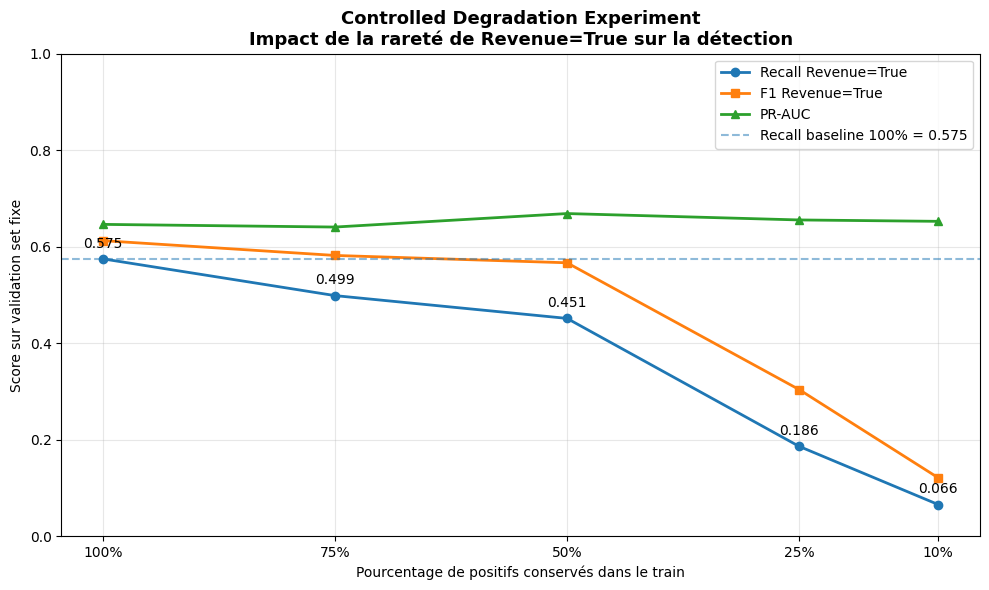

Figure sauvegardée : controlled_degradation_experiment.png


In [14]:
# ============================================================
# Cellule 14 — Figure de dégradation
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

x = df_degrad["Positives_Kept_pct"]

ax.plot(x, df_degrad["Recall_true"], marker="o", linewidth=2, label="Recall Revenue=True")
ax.plot(x, df_degrad["F1_true"], marker="s", linewidth=2, label="F1 Revenue=True")
ax.plot(x, df_degrad["PR_AUC"], marker="^", linewidth=2, label="PR-AUC")

for ratio, recall, f1, pr_auc in zip(
    x,
    df_degrad["Recall_true"],
    df_degrad["F1_true"],
    df_degrad["PR_AUC"]
):
    ax.annotate(
        f"{recall:.3f}",
        (ratio, recall),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

baseline_recall = df_degrad.loc[
    df_degrad["Positives_Kept_pct"] == 100,
    "Recall_true"
].iloc[0]

ax.axhline(
    baseline_recall,
    linestyle="--",
    alpha=0.5,
    label=f"Recall baseline 100% = {baseline_recall:.3f}"
)

ax.set_title(
    "Controlled Degradation Experiment\nImpact de la rareté de Revenue=True sur la détection",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Pourcentage de positifs conservés dans le train")
ax.set_ylabel("Score sur validation set fixe")
ax.set_xticks(x)
ax.set_xticklabels([f"{v}%" for v in x])
ax.invert_xaxis()
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("controlled_degradation_experiment.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure sauvegardée : controlled_degradation_experiment.png")

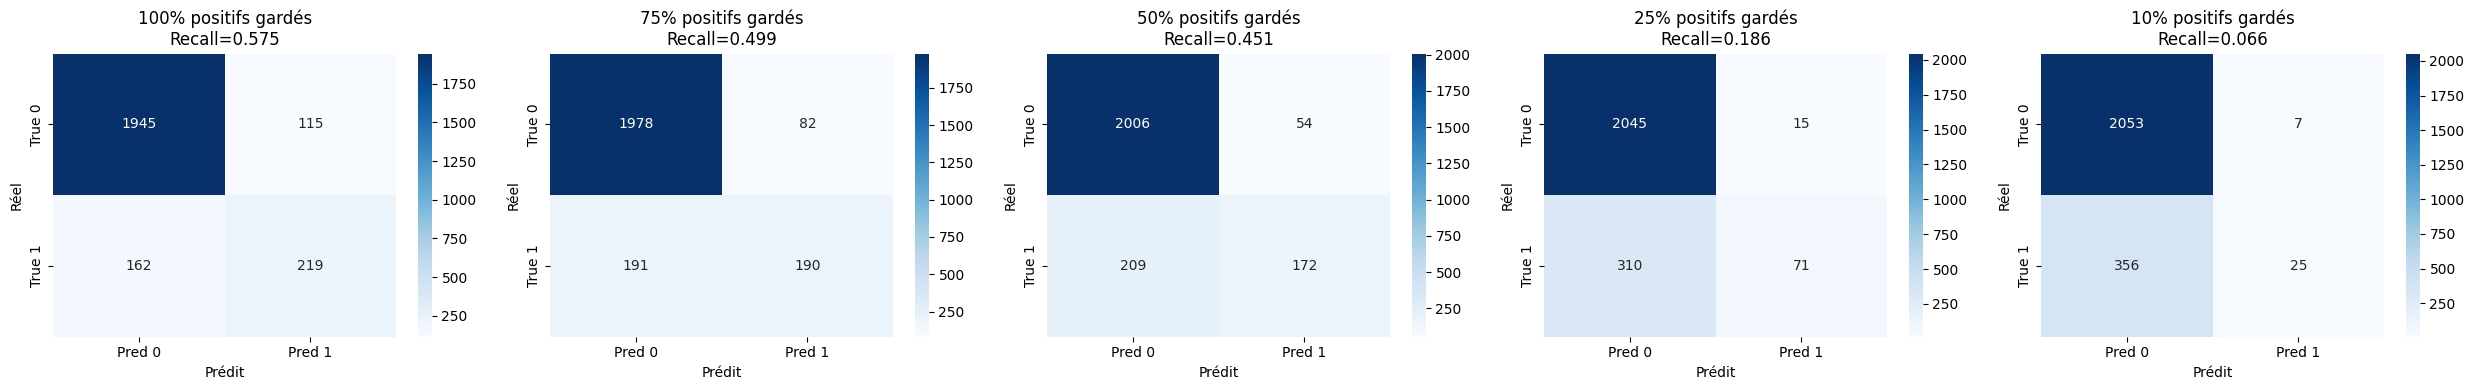

In [15]:
# ============================================================
# Cellule 15 — Matrices de confusion par ratio
# ============================================================

fig, axes = plt.subplots(1, len(DEGRADATION_RATIOS), figsize=(5 * len(DEGRADATION_RATIOS), 4))

if len(DEGRADATION_RATIOS) == 1:
    axes = [axes]

for ax, ratio in zip(axes, DEGRADATION_RATIOS):
    n_keep = max(1, int(n_pos_total * ratio))

    kept_pos_idx = pos_permutation[:n_keep]
    degraded_idx = np.concatenate([kept_pos_idx, neg_idx])
    degraded_idx = rng.permutation(degraded_idx)

    X_deg = X_train.loc[degraded_idx]
    y_deg = y_train.loc[degraded_idx]

    X_deg_proc = preprocessor.transform(X_deg)

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=TREE_MAX_DEPTH,
            random_state=RANDOM_STATE
        ),
        n_estimators=ADABOOST_N_ESTIMATORS,
        learning_rate=ADABOOST_LEARNING_RATE,
        algorithm="SAMME",
        random_state=RANDOM_STATE
    )

    model.fit(X_deg_proc, y_deg)

    metrics, y_pred, y_prob = evaluate_binary_model(
        model,
        X_val_proc,
        y_val,
        threshold=DECISION_THRESHOLD
    )

    cm = confusion_matrix(y_val, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )

    ax.set_title(
        f"{int(ratio*100)}% positifs gardés\nRecall={metrics['Recall_true']:.3f}"
    )
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Cellule 16 — Fonction flexible pour refaire l'expérience
# ============================================================

def run_degradation_experiment(
    degradation_ratios=[1.00, 0.75, 0.50, 0.25, 0.10],
    n_estimators=100,
    learning_rate=1.0,
    tree_max_depth=1,
    threshold=0.5,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    pos_idx = X_train.index[y_train == 1].to_numpy()
    neg_idx = X_train.index[y_train == 0].to_numpy()

    n_pos_total = len(pos_idx)
    n_neg_total = len(neg_idx)

    pos_permutation = rng.permutation(pos_idx)

    results = []

    for ratio in degradation_ratios:
        n_keep = max(1, int(n_pos_total * ratio))

        kept_pos_idx = pos_permutation[:n_keep]
        degraded_idx = np.concatenate([kept_pos_idx, neg_idx])
        degraded_idx = rng.permutation(degraded_idx)

        X_deg = X_train.loc[degraded_idx]
        y_deg = y_train.loc[degraded_idx]

        X_deg_proc = preprocessor.transform(X_deg)

        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=tree_max_depth,
                random_state=random_state
            ),
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            algorithm="SAMME",
            random_state=random_state
        )

        model.fit(X_deg_proc, y_deg)

        metrics, y_pred, y_prob = evaluate_binary_model(
            model,
            X_val_proc,
            y_val,
            threshold=threshold
        )

        results.append({
            "Positives_Kept_pct": int(ratio * 100),
            "N_positives_train": int(n_keep),
            "N_negatives_train": int(n_neg_total),
            "Actual_pos_rate_pct": y_deg.mean() * 100,
            "n_estimators": n_estimators,
            "learning_rate": learning_rate,
            "tree_max_depth": tree_max_depth,
            "threshold": threshold,
            **metrics
        })

    return pd.DataFrame(results)